# V-JEPA Training Evaluation
This notebook loads the training configurations, dataset paths, and plots the training metrics (loss, gradients) from the latest log files.

## 1. View Training Configuration
Let's load the configuration file used for training.

In [1]:
import yaml
import pprint

config_path = "configs/pretrain/vitt16.yaml"
with open(config_path, 'r') as f:
    config = yaml.load(f, Loader=yaml.FullLoader)

pprint.pprint(config)

{'app': 'vjepa',
 'data': {'batch_size': 2,
          'clip_duration': None,
          'crop_size': 224,
          'dataset_type': 'VideoDataset',
          'datasets': ['/home/bim/Documents/JEPA/nano-jepa/nano-train.csv'],
          'decode_one_clip': True,
          'filter_short_videos': False,
          'num_clips': 1,
          'num_frames': 16,
          'num_workers': 8,
          'patch_size': 16,
          'pin_mem': True,
          'sampling_rate': 4,
          'tubelet_size': 2},
 'data_aug': {'auto_augment': False,
              'motion_shift': False,
              'random_resize_aspect_ratio': [0.75, 1.35],
              'random_resize_scale': [0.3, 1.0],
              'reprob': 0.0},
 'logging': {'folder': '/home/bim/Documents/JEPA/nano-jepa/logs',
             'write_tag': 'jepa'},
 'loss': {'loss_exp': 1.0, 'reg_coeff': 0.0},
 'mask': [{'aspect_ratio': [0.75, 1.5],
           'max_keep': None,
           'max_temporal_keep': 1.0,
           'num_blocks': 8,
           '

## 2. Training Data Overview
Let's see what videos were used for training.

In [2]:
import pandas as pd

train_csv = "nano-train.csv"
try:
    df = pd.read_csv(train_csv, header=None, names=['video_path', 'label'], sep=' ')
    print(f"Total training videos: {len(df)}")
    display(df.head())
except Exception as e:
    print("Could not load data:", e)

Total training videos: 11


,video_path,label
0,/home/bim/Documents/JEPA/53990622708827221565.mp4,0
1,/home/bim/Documents/JEPA/82059798312815893204.mp4,0
2,/home/bim/Documents/JEPA/55420843463099559253.mp4,0
3,/home/bim/Documents/JEPA/88469299010302444222.mp4,0
4,/home/bim/Documents/JEPA/10322499402892092671.mp4,0


## 3. Training Metrics
We will find the latest CSV log file in the `logs/` directory and plot the loss and gradient norms.

Loading logs from: logs/2026-06-25_11-11-59-log_file.csv


,epoch,itr,loss,loss-jepa,reg-loss,enc-grad-norm,pred-grad-norm,gpu-time(ms),wall-time(ms)
0,1,0,0.87727,0.87727,0.82412,0.0,0.0,-1,42374
1,1,1,0.82232,0.82232,0.91450,0.0,0.0,-1,39410
2,1,2,0.78095,0.78095,0.93618,0.0,0.0,-1,24060
3,2,0,0.73471,0.73471,0.94900,0.0,0.0,-1,22614
4,2,1,0.72934,0.72934,0.95382,0.0,0.0,-1,22091


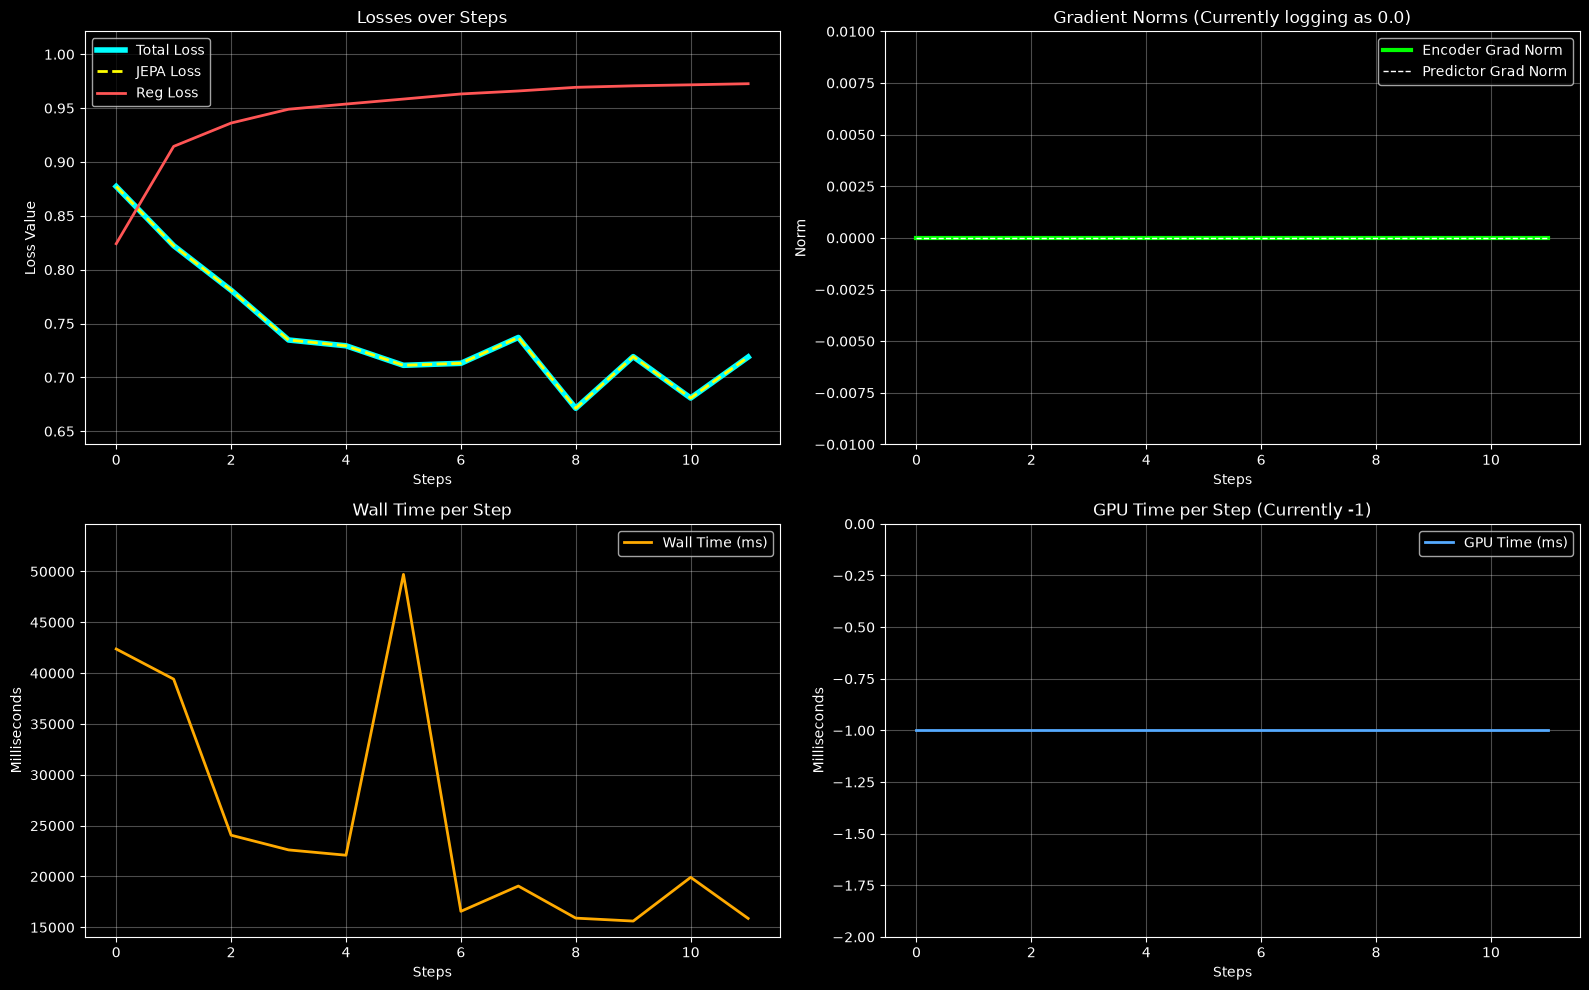

In [3]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('dark_background')

# Tìm file log mới nhất
log_files = glob.glob('logs/*-log_file.csv')
if not log_files:
    print("No log files found in logs/ directory.")
else:
    latest_log = max(log_files, key=os.path.getctime)
    print(f"Loading logs from: {latest_log}")
    
    df_logs = pd.read_csv(latest_log)
    display(df_logs.head())
    
    # Tạo 4 biểu đồ con (2x2) để vẽ hết tất cả các cột
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Biểu đồ Loss
    # Vì Total Loss và JEPA Loss bằng hệt nhau nên vẽ nét đứt (dashed) để thấy được cả hai
    axs[0, 0].plot(df_logs.index, df_logs['loss'], label='Total Loss', color='cyan', linewidth=4)
    axs[0, 0].plot(df_logs.index, df_logs['loss-jepa'], label='JEPA Loss', color='yellow', linewidth=2, linestyle='--')
    axs[0, 0].plot(df_logs.index, df_logs['reg-loss'], label='Reg Loss', color='#ff5555', linewidth=2)
    axs[0, 0].set_title('Losses over Steps')
    axs[0, 0].set_xlabel('Steps')
    axs[0, 0].set_ylabel('Loss Value')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)
    # Tự động scale Y-axis khít với đỉnh max/min của dữ liệu
    axs[0, 0].set_ylim(bottom=df_logs[['loss', 'loss-jepa', 'reg-loss']].min().min() * 0.95, 
                       top=df_logs[['loss', 'loss-jepa', 'reg-loss']].max().max() * 1.05)
    
    # 2. Biểu đồ Gradient Norms
    axs[0, 1].plot(df_logs.index, df_logs['enc-grad-norm'], label='Encoder Grad Norm', color='#00ff00', linewidth=3)
    axs[0, 1].plot(df_logs.index, df_logs['pred-grad-norm'], label='Predictor Grad Norm', color='white', linewidth=1, linestyle='--')
    axs[0, 1].set_title('Gradient Norms (Currently logging as 0.0)')
    axs[0, 1].set_xlabel('Steps')
    axs[0, 1].set_ylabel('Norm')
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)
    # Scale Y-axis
    axs[0, 1].set_ylim(-0.01, 0.01)
    
    # 3. Biểu đồ Wall Time
    axs[1, 0].plot(df_logs.index, df_logs['wall-time(ms)'], label='Wall Time (ms)', color='#ffaa00', linewidth=2)
    axs[1, 0].set_title('Wall Time per Step')
    axs[1, 0].set_xlabel('Steps')
    axs[1, 0].set_ylabel('Milliseconds')
    axs[1, 0].legend()
    axs[1, 0].grid(True, alpha=0.3)
    axs[1, 0].set_ylim(bottom=df_logs['wall-time(ms)'].min() * 0.9, top=df_logs['wall-time(ms)'].max() * 1.1)
    
    # 4. Biểu đồ GPU Time
    axs[1, 1].plot(df_logs.index, df_logs['gpu-time(ms)'], label='GPU Time (ms)', color='#55aaff', linewidth=2)
    axs[1, 1].set_title('GPU Time per Step (Currently -1)')
    axs[1, 1].set_xlabel('Steps')
    axs[1, 1].set_ylabel('Milliseconds')
    axs[1, 1].legend()
    axs[1, 1].grid(True, alpha=0.3)
    axs[1, 1].set_ylim(-2, 0)
    
    plt.tight_layout()
    plt.show()